In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, BertForTokenClassification, AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# BERT-based NER class
class BertNER(nn.Module):
    def __init__(self, tokens_dim):
        super(BertNER, self).__init__()
        
        if type(tokens_dim) != int:
            raise TypeError('tokens_dim should be an integer')
        if tokens_dim <= 0:
            raise ValueError('Classification layer dimension should be at least 1')

        self.pretrained = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels=tokens_dim)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass of the network.
        """
        if labels is None:
            return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    
    def save_pretrained(self, save_directory):
        """
        Save the pretrained model to the specified directory.
        """
        self.pretrained.save_pretrained(save_directory)

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
import torch
from torch.utils.data import Dataset
import ast

class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # Ensure the 'Ingredient_Phrases' column is a string
        text = str(row['Ingredient_Phrases'])

        # Convert 'Labels' from string representation to a list
        labels_list = ast.literal_eval(row['Labels'])  

        encoding = self.tokenizer(
            text.split(),  # Tokenize word by word
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            is_split_into_words=True  # Ensure token alignment with words
        )

        word_ids = encoding.word_ids(batch_index=0)  # Get token-word alignment
        label_ids = [-100] * self.max_len  # Default to ignored token

        # Assigning NER labels for each word token
        previous_word_id = None
        for i, word_id in enumerate(word_ids):
            if word_id is None:
                label_ids[i] = -100  # Padding or special tokens
            elif word_id != previous_word_id:
                label_ids[i] = self.label_map.get(labels_list[word_id], -100)  # Assign the correct label
            else:
                label_ids[i] = label_ids[i-1]  # For subwords, keep same label
            previous_word_id = word_id

        input_ids = encoding['input_ids'].squeeze(0)  # Remove batch dimension
        attention_mask = encoding['attention_mask'].squeeze(0)  # Remove batch dimension
        label_ids = torch.tensor(label_ids, dtype=torch.long)  # Convert to tensor

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

# Label mapping 
label_map = {
    'QUANTITY': 0,
    'UNIT': 1,
    'NAME': 2,
    'FORM': 3,
    'STATE': 4,
    'DF': 5,
    'SIZE': 6,
    'O': -100  # Outside token or padding
}

from sklearn.model_selection import train_test_split
df = pd.read_csv('../../data/processed/10k_data_modified.csv')

- train + test split 

In [3]:
#ner_dataset = NerDataset(df, tokenizer, label_map)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


model = BertNER(tokens_dim=len(label_map))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


- train test val split

In [ ]:
#ner_dataset = NerDataset(df, tokenizer, label_map)
train_df_, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df_, test_size=0.2, random_state=42)

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
val_dataset = NerDataset(dataframe=val_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


model = BertNER(tokens_dim=len(label_map))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training settings
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


BertNER(
  (pretrained): BertForTokenClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(28996, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, 

In [6]:
torch.cuda.set_device(1)  # Set GPU 1 as the active device
print("Now using GPU:", torch.cuda.current_device())

Now using GPU: 1


In [5]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())
print("CUDA Device Name:", torch.cuda.get_device_name(0))
print("Current CUDA Device:", torch.cuda.current_device())

CUDA Available: True
CUDA Device Count: 2
CUDA Device Name: NVIDIA A100-PCIE-40GB
Current CUDA Device: 0


# MODEL TRAINING

- validation + training 

Epoch 1/5 [Training]:   0%|          | 0/432 [00:00<?, ?it/s]

Epoch 1/5 [Training]: 100%|██████████| 432/432 [01:30<00:00,  4.78it/s, Train Loss=0.0110]


Epoch 1/5, Train Loss: 0.2019, Val Loss: 0.0725


Epoch 2/5 [Training]: 100%|██████████| 432/432 [01:31<00:00,  4.74it/s, Train Loss=0.0398]


Epoch 2/5, Train Loss: 0.0579, Val Loss: 0.0698


...

Epoch 3/5, Train Loss: 0.0401, Val Loss: 0.0667


Epoch 4/5 [Training]: 100%|██████████| 432/432 [01:30<00:00,  4.75it/s, Train Loss=0.0034]


Epoch 4/5, Train Loss: 0.0288, Val Loss: 0.0676


Epoch 5/5 [Training]: 100%|██████████| 432/432 [01:31<00:00,  4.73it/s, Train Loss=0.0327]


Epoch 5/5, Train Loss: 0.0240, Val Loss: 0.0684


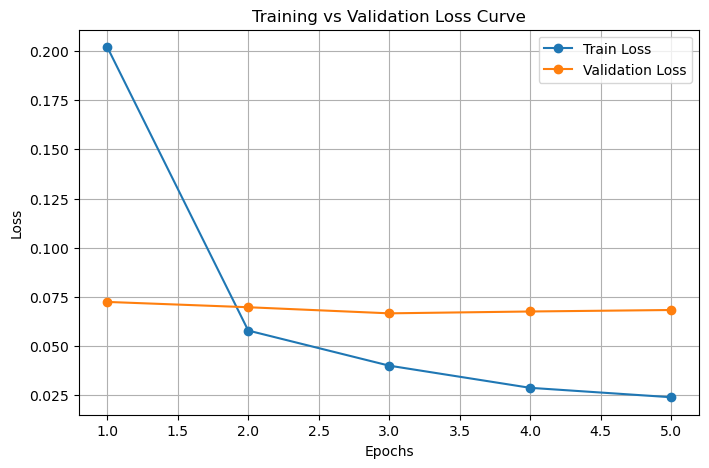

In [17]:
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm for progress bars

# Lists to store losses
train_losses = []
val_losses = []

for epoch in range(epochs):
    total_train_loss = 0
    total_val_loss = 0

    # Training phase
    model.train()
    train_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")  

    for batch in train_iterator:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_iterator.set_postfix({"Train Loss": f"{loss.item():.4f}"})  # Update tqdm bar

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase (no gradient updates)
    model.eval()
    val_iterator = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

    with torch.no_grad():
        for batch in val_iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            total_val_loss += loss.item()
            val_iterator.set_postfix({"Val Loss": f"{loss.item():.4f}"})  # Update tqdm bar

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Plot Training vs Validation Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss", marker='o', linestyle='-')
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

- early stopping + training

In [11]:
import torch
import numpy as np
from tqdm import tqdm

# Train
train_losses = []
val_losses = []
patience = 3  # Stop training if validation loss does not improve for 'patience' epochs
best_val_loss = np.inf  # Initialize best validation loss as infinity
early_stop_counter = 0  # Tracks epochs without improvement
epochs = 8

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    # Training Loop
    model.train()
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update tqdm description with latest loss
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)  # Store training loss

    # Validation Step
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:  # Assuming you have a validation DataLoader
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)  # Store validation loss

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss  # Update best validation loss
        early_stop_counter = 0  # Reset counter
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered! Stopping training.")
        break  # Stop training

Epoch 1/8, Train Loss: 0.2328, Validation Loss: 0.1177


Epoch 2/8, Train Loss: 0.0844, Validation Loss: 0.0944


Epoch 3/8, Train Loss: 0.0628, Validation Loss: 0.1105
Early stopping counter: 1/3


Epoch 4/8, Train Loss: 0.0507, Validation Loss: 0.0993
Early stopping counter: 2/3


Epoch 5/8, Train Loss: 0.0398, Validation Loss: 0.1140
Early stopping counter: 3/3
Early stopping triggered! Stopping training.


- cross fold validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold  # To check for imbalance
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm  # Import tqdm for progress bars

k_folds = 5  # Number of folds
batch_size = 16
epochs = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Convert DataFrame to NumPy for indexing
df_np = df.to_numpy()
fold_results = []

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# for fold, (train_idx, val_idx) in enumerate(skf.split(df_np, df["Labels"])):  # Use your label column

for fold, (train_idx, val_idx) in enumerate(kf.split(df_np)):
    print(f"\n{'-'*30}\nFold {fold+1}/{k_folds}\n{'-'*30}")

    train_df = pd.DataFrame(df_np[train_idx], columns=df.columns)
    val_df = pd.DataFrame(df_np[val_idx], columns=df.columns)

    # Create datasets
    train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
    val_dataset = NerDataset(dataframe=val_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = BertNER(tokens_dim=len(label_map)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    # Training loop
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        total_train_loss = 0
        total_val_loss = 0

        # Training phase
        model.train()
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

        for batch in train_bar:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        predictions = []
        true_labels = []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)
        with torch.no_grad():
            for batch in val_bar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                logits = logits.detach().cpu().numpy()
                labels = labels.cpu().numpy()

                for i in range(len(labels)):
                    pred_labels = []
                    true_label = []
                    for j in range(len(labels[i])):
                        if labels[i][j] != -100:  # Ignore padding
                            true_label.append(labels[i][j])
                            pred_label = np.argmax(logits[i][j])
                            pred_labels.append(pred_label)

                    predictions.append(pred_labels)
                    true_labels.append(true_label)

                loss = outputs.loss
                total_val_loss += loss.item()
                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Flatten the lists for metric calculation
    flat_predictions = [item for sublist in predictions for item in sublist]
    flat_true_labels = [item for sublist in true_labels for item in sublist]

    # Compute Metrics
    precision = precision_score(flat_true_labels, flat_predictions, average="macro")
    recall = recall_score(flat_true_labels, flat_predictions, average="macro")
    f1 = f1_score(flat_true_labels, flat_predictions, average="macro")

    print(f"\nClassification Report for Fold {fold+1}:")
    print(classification_report(flat_true_labels, flat_predictions, digits=4))

    fold_results.append({
        'train_losses': train_losses,
        'val_losses': val_losses,
        'classification_report': classification_report(flat_true_labels, flat_predictions, digits=4, output_dict=True),
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Aggregate results from all folds
avg_train_loss_per_epoch = np.mean([fold['train_losses'] for fold in fold_results], axis=0)
avg_val_loss_per_epoch = np.mean([fold['val_losses'] for fold in fold_results], axis=0)

# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), avg_train_loss_per_epoch, label="Avg Train Loss", marker='o', linestyle='-')
plt.plot(range(1, epochs + 1), avg_val_loss_per_epoch, label="Avg Validation Loss", marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"{k_folds}-Fold Cross-Validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

- Training

In [5]:
from tqdm import tqdm

# Train
train_losses = []

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update tqdm description with the latest loss
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)  # Store loss

    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

Epoch 1/5, Average Loss: 0.1670


Epoch 2/5, Average Loss: 0.0539


Epoch 3/5, Average Loss: 0.0389


Epoch 4/5, Average Loss: 0.0284


Epoch 5/5, Average Loss: 0.0228


# EVALUATION

In [6]:
# Evaluation 
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print("Bert-base results:")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Bert-base results:
Precision: 0.9744
Recall: 0.9761
F1-Score: 0.9752
              precision    recall  f1-score   support

           0     0.9973    0.9965    0.9969      3710
           1     0.9889    0.9970    0.9929      2672
           2     0.9836    0.9891    0.9863      6133
           3     0.9376    0.9142    0.9257      1002
           4     0.9892    0.9786    0.9838      3267
           5     0.9688    1.0000    0.9841       186
           6     0.9558    0.9576    0.9567       542

    accuracy                         0.9848     17512
   macro avg     0.9744    0.9761    0.9752     17512
weighted avg     0.9847    0.9848    0.9847     17512



: 